In [2]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer
)

from xgboost import XGBClassifier


# =========================================================
# 1. LOAD AND TRANSFORM MATCH DATA
# =========================================================

df = pd.read_csv("data.csv")

rows = []

for idx, row in df.iterrows():

    clean_score = re.sub(r'\(.*?\)', '', str(row['score'])).replace('–', '-').strip()

    try:
        score_parts = clean_score.split('-')
        home_score = int(score_parts[0].strip())
        away_score = int(score_parts[1].strip())
    except:
        continue

    # PPDA proxy used in this project
    home_ppda = row['away_completed_passes'] / max(
        row['home_tackles'] + row['home_interceptions'], 1
    )

    away_ppda = row['home_completed_passes'] / max(
        row['away_tackles'] + row['away_interceptions'], 1
    )

    # Relative aerial/50-50 duel share used by the prototype
    total_aerials = max(
        row['home_aerials_won'] + row['away_aerials_won'], 1
    )

    home_aerial_pct = row['home_aerials_won'] / total_aerials * 100
    away_aerial_pct = row['away_aerials_won'] / total_aerials * 100

    home_outcome = (
        'Win' if home_score > away_score
        else 'Loss' if home_score < away_score
        else 'Draw'
    )

    away_outcome = (
        'Win' if away_score > home_score
        else 'Loss' if away_score < home_score
        else 'Draw'
    )

    # IMPORTANT:
    # Both team rows from the same real match receive the SAME match_id.
    match_id = f"{row['tournament']}_{idx}"

    rows.append({
        'match_id': match_id,
        'tournament': row['tournament'],
        'xg': float(row['home_xg']),
        'possession': float(row['home_possession']),
        'shots_on_target': float(row['home_sot']),
        'ppda': float(home_ppda),
        'tackles_successful': float(row['home_tackles']),
        'interceptions': float(row['home_interceptions']),
        'aerial_duels_won_pct': float(home_aerial_pct),
        'outcome': home_outcome
    })

    rows.append({
        'match_id': match_id,
        'tournament': row['tournament'],
        'xg': float(row['away_xg']),
        'possession': float(row['away_possession']),
        'shots_on_target': float(row['away_sot']),
        'ppda': float(away_ppda),
        'tackles_successful': float(row['away_tackles']),
        'interceptions': float(row['away_interceptions']),
        'aerial_duels_won_pct': float(away_aerial_pct),
        'outcome': away_outcome
    })


team_df = pd.DataFrame(rows)

FEATURES = [
    'xg',
    'possession',
    'shots_on_target',
    'ppda',
    'tackles_successful',
    'interceptions',
    'aerial_duels_won_pct'
]


# =========================================================
# 2. CHRONOLOGICAL SPLIT
# =========================================================
# Earlier competitions are used for model development only.
# Future competitions remain untouched during model selection.

train_df = team_df[
    team_df['tournament'].isin([
        'World Cup 2018',
        'Euro 2020'
    ])
].copy()

future_test_df = team_df[
    team_df['tournament'].isin([
        'World Cup 2022',
        'Euro 2024',
        'Copa America 2024'
    ])
].copy()

print("Development samples:", len(train_df))
print("Development matches:", train_df['match_id'].nunique())

print("Future test samples:", len(future_test_df))
print("Future test matches:", future_test_df['match_id'].nunique())

Development samples: 230
Development matches: 115
Future test samples: 294
Future test matches: 147


In [3]:
# =========================================================
# 3. MODEL SELECTION USING EARLIER DATA ONLY
# =========================================================

X_dev = train_df[FEATURES]
y_dev_text = train_df['outcome']
groups = train_df['match_id']

label_encoder = LabelEncoder()
y_dev = label_encoder.fit_transform(y_dev_text)

models = {

    "Dummy Majority": DummyClassifier(
        strategy="most_frequent"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ),

    "MLP": make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(16,),
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            max_iter=1000,
            random_state=42
        )
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric="mlogloss"
    )
}


# Keeps two rows from the same football match in the same fold.
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",

    "precision_macro": make_scorer(
        precision_score,
        average="macro",
        zero_division=0
    ),

    "recall_macro": make_scorer(
        recall_score,
        average="macro",
        zero_division=0
    ),

    "f1_macro": make_scorer(
        f1_score,
        average="macro",
        zero_division=0
    )
}


comparison_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_dev,
        y_dev,
        cv=cv,
        groups=groups,
        scoring=scoring
    )

    comparison_results.append({
        "Model": model_name,

        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),

        "Macro Precision": scores["test_precision_macro"].mean(),
        "Macro Recall": scores["test_recall_macro"].mean(),
        "Macro F1": scores["test_f1_macro"].mean()
    })


comparison_df = pd.DataFrame(comparison_results)

print("\nMODEL COMPARISON — DEVELOPMENT PERIOD ONLY")
print(comparison_df.round(4))

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perce


MODEL COMPARISON — DEVELOPMENT PERIOD ONLY
            Model  Accuracy  Accuracy SD  Macro Precision  Macro Recall  \
0  Dummy Majority    0.3913       0.0364           0.1304        0.3333   
1   Random Forest    0.5478       0.0522           0.6052        0.5122   
2             MLP    0.5304       0.1203           0.5725        0.5158   
3         XGBoost    0.5435       0.0567           0.5625        0.5286   

   Macro F1  
0    0.1872  
1    0.5155  
2    0.5162  
3    0.5162  


In [4]:
# =========================================================
# 4. FINAL CHRONOLOGICAL EVALUATION
# =========================================================
# Random Forest is selected from the development-stage CV.
# The future period is now opened ONCE for final evaluation.

rf_evaluation_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

rf_evaluation_model.fit(
    train_df[FEATURES],
    train_df['outcome']
)

X_future = future_test_df[FEATURES]
y_future = future_test_df['outcome']

future_prediction = rf_evaluation_model.predict(X_future)

print("\nFINAL CHRONOLOGICAL TEST")
print("--------------------------------")

print(
    "Accuracy:",
    round(accuracy_score(y_future, future_prediction), 4)
)

print(
    "Macro Precision:",
    round(
        precision_score(
            y_future,
            future_prediction,
            average="macro",
            zero_division=0
        ), 4
    )
)

print(
    "Macro Recall:",
    round(
        recall_score(
            y_future,
            future_prediction,
            average="macro",
            zero_division=0
        ), 4
    )
)

print(
    "Macro F1:",
    round(
        f1_score(
            y_future,
            future_prediction,
            average="macro",
            zero_division=0
        ), 4
    )
)

print("\nClassification Report")
print(
    classification_report(
        y_future,
        future_prediction,
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix [Win, Draw, Loss]")
print(
    confusion_matrix(
        y_future,
        future_prediction,
        labels=['Win', 'Draw', 'Loss']
    )
)



FINAL CHRONOLOGICAL TEST
--------------------------------
Accuracy: 0.585
Macro Precision: 0.6319
Macro Recall: 0.562
Macro F1: 0.5541

Classification Report
              precision    recall  f1-score   support

        Draw     0.7667    0.2805    0.4107        82
        Loss     0.5680    0.6698    0.6147       106
         Win     0.5612    0.7358    0.6367       106

    accuracy                         0.5850       294
   macro avg     0.6319    0.5620    0.5541       294
weighted avg     0.6209    0.5850    0.5658       294


Confusion Matrix [Win, Draw, Loss]
[[78  5 23]
 [28 23 31]
 [33  2 71]]


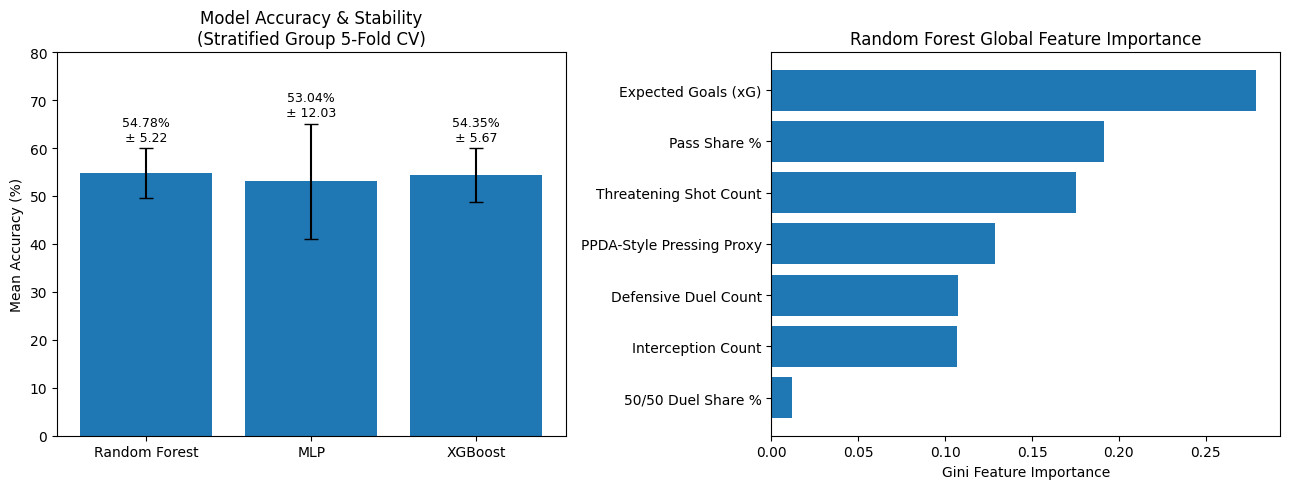

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

FEATURE_LABELS = {
    "xg": "Expected Goals (xG)",
    "possession": "Pass Share %",
    "shots_on_target": "Threatening Shot Count",
    "ppda": "PPDA-Style Pressing Proxy",
    "tackles_successful": "Defensive Duel Count",
    "interceptions": "Interception Count",
    "aerial_duels_won_pct": "50/50 Duel Share %"
}

# =========================================================
# FIGURE 4.1
# Model Comparison + Random Forest Feature Importance
# =========================================================

# Remove Dummy classifier from the visual comparison
plot_df = comparison_df[
    comparison_df["Model"] != "Dummy Majority"
].copy()

# Convert accuracy values to percentages
accuracy_pct = plot_df["Accuracy"] * 100
accuracy_sd_pct = plot_df["Accuracy SD"] * 100

# -----------------------------
# Create figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# =========================================================
# LEFT: Model Accuracy Comparison
# =========================================================

axes[0].bar(
    plot_df["Model"],
    accuracy_pct,
    yerr=accuracy_sd_pct,
    capsize=5
)

axes[0].set_title(
    "Model Accuracy & Stability\n(Stratified Group 5-Fold CV)"
)

axes[0].set_ylabel("Mean Accuracy (%)")
axes[0].set_ylim(0, 80)

for i, (acc, sd) in enumerate(zip(accuracy_pct, accuracy_sd_pct)):
    axes[0].text(
        i,
        acc + sd + 1.5,
        f"{acc:.2f}%\n± {sd:.2f}",
        ha="center",
        fontsize=9
    )

# =========================================================
# RIGHT: Random Forest Feature Importance
# =========================================================

importance_df = pd.DataFrame({
    "Feature": [FEATURE_LABELS[f] for f in FEATURES],
    "Importance": rf_evaluation_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=True
)

axes[1].barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

axes[1].set_title(
    "Random Forest Global Feature Importance"
)

axes[1].set_xlabel("Gini Feature Importance")


plt.tight_layout()

plt.savefig(
    "figure_4_1_model_comparison_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=" * 65)
print("FINAL CHRONOLOGICAL EVALUATION — FUTURE DATA 2022–2024")
print("=" * 65)

print(f"\nDevelopment period : 2018 World Cup + Euro 2020")
print(f"Future test period : World Cup 2022 + Euro 2024 + Copa America 2024")

print(f"\nTraining team samples : {len(train_df)}")
print(f"Future test samples   : {len(future_test_df)}")

print("\nOVERALL PERFORMANCE")
print("-" * 40)

print(
    f"Accuracy        : "
    f"{accuracy_score(y_future, future_prediction):.4f}"
)

print(
    f"Macro Precision : "
    f"{precision_score(y_future, future_prediction, average='macro', zero_division=0):.4f}"
)

print(
    f"Macro Recall    : "
    f"{recall_score(y_future, future_prediction, average='macro', zero_division=0):.4f}"
)

print(
    f"Macro F1-Score  : "
    f"{f1_score(y_future, future_prediction, average='macro', zero_division=0):.4f}"
)


print("\nCLASSIFICATION REPORT")
print("-" * 65)

print(
    classification_report(
        y_future,
        future_prediction,
        labels=["Win", "Draw", "Loss"],
        digits=4,
        zero_division=0
    )
)


print("CONFUSION MATRIX")
print("(Rows = Actual, Columns = Predicted)")
print("-" * 65)

cm = confusion_matrix(
    y_future,
    future_prediction,
    labels=["Win", "Draw", "Loss"]
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Win",
        "Actual Draw",
        "Actual Loss"
    ],
    columns=[
        "Pred Win",
        "Pred Draw",
        "Pred Loss"
    ]
)

print(cm_df)

FINAL CHRONOLOGICAL EVALUATION — FUTURE DATA 2022–2024

Development period : 2018 World Cup + Euro 2020
Future test period : World Cup 2022 + Euro 2024 + Copa America 2024

Training team samples : 230
Future test samples   : 294

OVERALL PERFORMANCE
----------------------------------------
Accuracy        : 0.5850
Macro Precision : 0.6319
Macro Recall    : 0.5620
Macro F1-Score  : 0.5541

CLASSIFICATION REPORT
-----------------------------------------------------------------
              precision    recall  f1-score   support

         Win     0.5612    0.7358    0.6367       106
        Draw     0.7667    0.2805    0.4107        82
        Loss     0.5680    0.6698    0.6147       106

    accuracy                         0.5850       294
   macro avg     0.6319    0.5620    0.5541       294
weighted avg     0.6209    0.5850    0.5658       294

CONFUSION MATRIX
(Rows = Actual, Columns = Predicted)
-----------------------------------------------------------------
             Pred W

In [7]:
# =========================================================
# 5. TRAIN FINAL DEPLOYMENT MODEL
# =========================================================
# After evaluation is complete, the production model may use
# all historical data available to the 2026 prototype.

clean_master_dataset = team_df[
    FEATURES + ['outcome']
].copy()

clean_master_dataset.to_csv(
    "clean_master_dataset.csv",
    index=False
)

deployment_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

deployment_model.fit(
    clean_master_dataset[FEATURES],
    clean_master_dataset['outcome']
)

joblib.dump(
    deployment_model,
    "world_cup_rf_model_v2.pkl"
)

print("\nDeployment model saved successfully.")


Deployment model saved successfully.


In [8]:
# =========================================================
# 6. SAVE COMPARISON MODELS FOR STREAMLIT DASHBOARD
# =========================================================

import joblib

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


# ---------------------------------------------------------
# Use the same 7 deployment features as Random Forest
# ---------------------------------------------------------

X_all = clean_master_dataset[FEATURES].copy()
y_all = clean_master_dataset["outcome"].copy()


# =========================================================
# 1. MLP DEPLOYMENT MODEL
# =========================================================

# StandardScaler is included inside the pipeline,
# so Streamlit can directly send the same raw 7 features.

mlp_deployment_model = make_pipeline(
    StandardScaler(),

    MLPClassifier(
        hidden_layer_sizes=(16,),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    )
)

mlp_deployment_model.fit(
    X_all,
    y_all
)


# =========================================================
# 2. XGBOOST DEPLOYMENT MODEL
# =========================================================

# XGBoost requires numeric target labels.
# LabelEncoder is only used for XGBoost.

xgb_label_encoder = LabelEncoder()

y_xgb = xgb_label_encoder.fit_transform(
    y_all
)

xgb_deployment_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_deployment_model.fit(
    X_all,
    y_xgb
)


# =========================================================
# 3. SAVE EVERYTHING INTO ONE FILE
# =========================================================

comparison_bundle = {

    # Models
    "mlp_model": mlp_deployment_model,
    "xgb_model": xgb_deployment_model,

    # Needed to translate XGBoost 0/1/2
    # back into Draw/Loss/Win
    "xgb_classes": list(
        xgb_label_encoder.classes_
    ),

    # Keep feature order explicit
    "features": FEATURES,

    # Store the development-stage CV results
    # already generated earlier in this notebook
    "cv_metrics": comparison_df.to_dict(
        orient="records"
    )
}


joblib.dump(
    comparison_bundle,
    "comparison_models.pkl"
)


print("Comparison models saved successfully.")
print("File created: comparison_models.pkl")

print("\nXGBoost class order:")
print(
    list(xgb_label_encoder.classes_)
)

Comparison models saved successfully.
File created: comparison_models.pkl

XGBoost class order:
['Draw', 'Loss', 'Win']
